In [5]:
# Step 1:shap_analysis.ipynb
# Apply SHAP to Random Forest model
# SHAP = SHapley Additive exPlanations
# explains WHY model made each prediction
# based on game theory ()

import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

print("Loading model and data...")
save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# Load saved files
X_train = np.load(save_path + "X_train.npy")
X_test = np.load(save_path + "X_test.npy")
y_test = pd.read_csv(save_path + "y_test.csv").squeeze()

# Load trained RF model
rf_model = joblib.load(save_path + "rf_model.joblib")

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("Model and data loaded!")


Loading model and data...
X_train: (1979513, 80)
X_test: (848363, 80)
Model and data loaded!


In [7]:
# Step 2: Create SHAP explainer
# TreeExplainer = fast SHAP for tree models like Ramdom Forest

print("Create SHAP explainer...")
print("This may take 1-2 minutes...")

# Use small sample for SHAP
# (full 848K records = too slow!)
# 500 samples = enough for explanation

import numpy as np
sample_idx = np.random.choice(
    len(X_test),
    size = 500,
    replace = False
)
X_sample = X_test[sample_idx]
y_sample = y_test.iloc[sample_idx]

print(f"Sample size: {X_sample.shape}")

# Create TreeExplainer
explainer = shap.TreeExplainer(rf_model)
print("SHAP explainer created!")


Create SHAP explainer...
This may take 1-2 minutes...
Sample size: (500, 80)
SHAP explainer created!


In [12]:
# Step 3: Calculate SHAP values
# This explains each prediction
# for all 500 sample records

print("Calculating SHAP values...")
print("Please wait 3-5 minutes...")

import time
start_time = time.time()

# Calculate SHAP values
# shape_values shape = (samples, features classes)
shap_values = explainer.shap_values(X_sample)

end_time = time.time()
shap_time = round(end_time - start_time, 2)

print(f"SHAP calculate complete!")
print(f"Time taken: {shap_time} seconds")
print(f"SHAP values type: {type(shap_values)}")

# check shape
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"Shape per class: {shap_values[0].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")

Calculating SHAP values...
Please wait 3-5 minutes...
SHAP calculate complete!
Time taken: 109.99 seconds
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (500, 80, 13)


In [11]:
# Step 4: Visualize SHAP results
# Global feature importance = which features matter most OVERALL

# Load feature names
X_clean = pd.read_csv(
    save_path + "y_train.csv"
)

# Get feature names form preprocessing
import numpy as np
import pandas as pd
import glob

# Reload one file to get column names
path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/cicids_db/*.csv"
files = glob.glob(path)
df_sample = pd.read_csv(files[0], nrows=5)
df_sample.columns = df_sample.columns.str.strip()

# Get feature names(remove non-numeric)
non_numeric = ['Flow ID', 'Source IP',
              'Destination IP', 'Timestamp',
              'Label']
feature_names = [c for c in df_sample.columns
                if c not in non_numeric]
print(f"Feature names loaded: {len(feature_names)}")
print(f"First 5: {feature_names[:5]}")


Feature names loaded: 80
First 5: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets']


Generating SHAP summary plot...


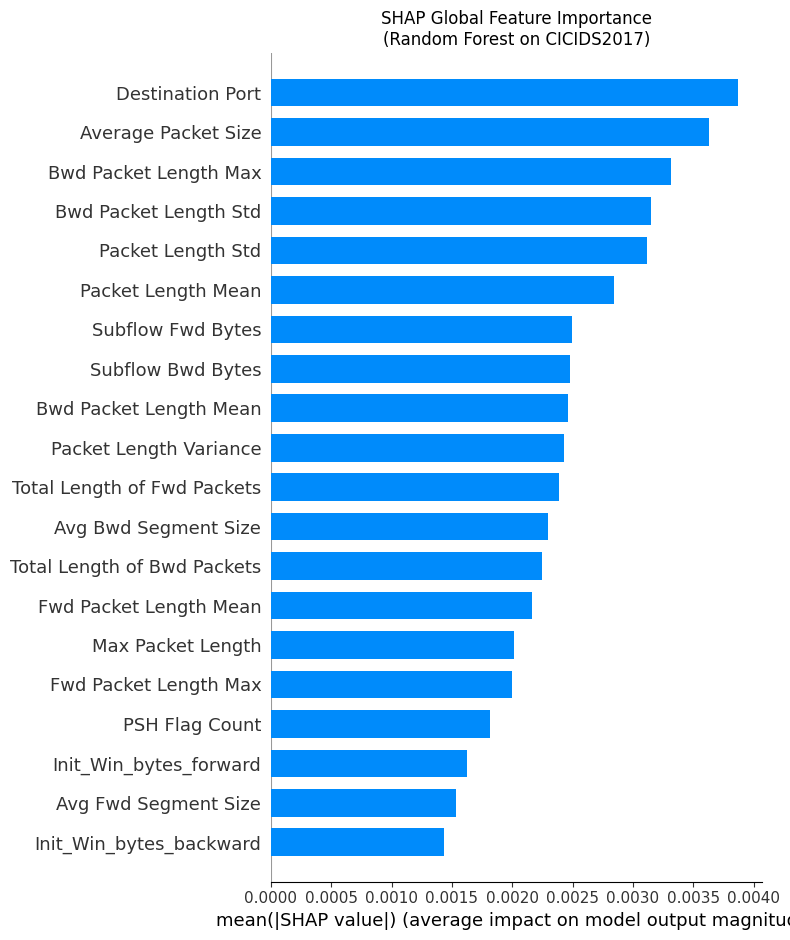

SHAP plot saved!


In [13]:
# Step 5: Plot SHAP global feature importance
# Shows which features matter most accrss all 13 attack classes
import numpy as np
print("Generating SHAP summary plot...")

# Mean adsolute SHAP values across all classes
# shape: (500, 80, 13) -> mean across classes

shap_mean = np.mean(
    np.abs(shap_values), axis=2)
# Plot top 20 most important features
plt.figure(figsize =(10,8))
shap.summary_plot(
    shap_mean,
    X_sample,
    feature_names = feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Global Feature Importance\n(Random Forest on CICIDS2017)")
plt.tight_layout()
plt.savefig(save_path + "shape_global.png",
           dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

In [15]:
# copy benchmark repo
import os
import shutil

src = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/shape_global.png"
dst_folder = "/Users/miuyanhong/Desktop/TCSS499_Research_Benchmark/results/"
os.makedirs(dst_folder, exist_ok=True)  # create folder if missing
dst = dst_folder + "shape_global.png"

if os.path.exists(src):
    shutil.copy(src, dst)
    print("Plot copied! ✅")
else:
    print(f"ERROR: Source file not found: {src}")


Plot copied! ✅
